#**CHAPTER 8.DIFUSSION MODELS**
---

##REFERENCE

https://chatgpt.com/share/69a86ff9-e374-8012-981b-4617538c0f25

##0.CONTEXT

*Introduction*

Chapter 8 introduces diffusion models through the smallest possible mechanism that still preserves what makes the family conceptually distinctive: generation is not performed in a single jump from a latent vector to a sample. Instead, generation is performed by learning a *reverse process* that incrementally removes noise, step by step, until the sample becomes structured. The notebook is intentionally “mechanics-first.” It avoids large image datasets and heavy architectures so that the student can see, in a controlled setting, what the diffusion procedure is actually doing. The entire experiment is built on a synthetic two-dimensional mixture of Gaussians. This choice is deliberate: in two dimensions you can literally watch probability mass move through space as denoising proceeds, and you can verify success or failure by eye without needing complicated evaluation tooling.

Historically, diffusion models can be understood as a response to a core difficulty in generative modeling: learning a complicated data distribution directly is hard, and learning it with stable training dynamics is even harder. Many generative approaches attempt to learn a mapping from a simple distribution (like a Gaussian) into the data distribution. Diffusion models do something different. They define a *forward corruption process* that gradually transforms real data into almost pure noise. Because this forward process is constructed by us, it is well-defined, easy to simulate, and behaves predictably. The learning problem is then reframed: instead of learning “data distribution → noise” or “noise → data” in one step, we train a model to predict how to undo a small portion of the corruption at each step. This is a crucial structural assumption: the model is trained to solve many small denoising problems, each conditioned on a time index, rather than one large “generate everything” problem.

This notebook emphasizes the distinction between training and inference in a way that is unusually clean. During training, we start with a real data point \(x_0\), pick a time step \(t\), add a controlled amount of Gaussian noise to obtain \(x_t\), and train a neural network to predict the noise that was added. The training signal is a stable regression loss (mean squared error) on noise prediction. Nothing is “generated” during training in the sense of producing new samples from scratch; training is about learning the denoising operator across many corruption levels. Inference is where generation happens: we begin from pure noise (the endpoint of the forward process) and repeatedly apply the learned reverse steps until the point cloud becomes structured. This separation is not a cosmetic detail. It is the defining operational pattern of diffusion models: training is a supervised denoising problem; inference is an iterative sampling procedure.

Visualization is central to the learning goal. In a two-dimensional synthetic world, the student can track how noise gradually collapses into modes that match the cluster structure of the data. Cell 9 is the interpretability anchor: it shows snapshots of the point cloud at multiple reverse time steps. The student should observe that early denoising steps do not “snap” points into their final clusters; they reshape the distribution gradually. This makes diffusion models feel less like “a generator that dreams up samples” and more like “a learned refinement process.” That refinement process is the conceptual bridge to later chapters and more complex data types: images, sequences, or graphs can also be treated as objects that can be noised and then denoised.

Because everything is synthetic, the notebook stays focused on mechanism rather than dataset idiosyncrasies. The data generator is deterministic, parameterized, and simple enough that the student can reason about what a “correct” distribution should look like. Normalization is applied explicitly so the model sees numerically stable inputs. A train/test split is enforced to keep the workflow disciplined even in a toy setting. Loss curves are plotted so the student can connect “the model learns” to actual numeric behavior. Ablation is included so the student can see why diffusion inference is iterative: fewer reverse steps typically degrade sample quality, revealing that the generative capability is distributed across time rather than concentrated in a single forward pass.

By the end of Chapter 8, the student should be able to answer a very specific mechanical question: if you hand me a trained diffusion denoiser, what exactly happens when I generate samples? The answer is not “I call model(z).” The answer is “I run a loop over timesteps, and at each timestep I use the model’s time-conditioned prediction to compute a reverse update.” This notebook is designed to make that loop feel tangible, inspectable, and inevitable.

##1.LIBRARIES AND ENVIRONMENT

**Cell 1 — Imports, determinism, device selection, and shared plotting/training utilities**

Cell 1 establishes the shared infrastructure used across the ML & AI 101 laboratory series, and it does so in a way that reinforces a key pedagogical point: reliable experimentation is not only about the model; it is also about consistent execution conditions and consistent visualization. The first thing this cell does is import only the allowed libraries: Python standard utilities, numpy, matplotlib, and torch. This matters because it forces the notebook to implement the key mechanics directly rather than outsourcing them to high-level frameworks. In diffusion models, where the learning objective and sampling loop are the main conceptual content, hiding steps behind abstractions would undermine the goal of the chapter.

The determinism block is essential for learning. By fixing random seeds for Python, numpy, and torch (including CUDA), the notebook ensures that the synthetic dataset, the noise draws used during diffusion, and the optimization trajectory are reproducible. This enables the student to make meaningful comparisons when they change one variable later (for example, the number of reverse steps in the stress test). Without determinism, a student might confuse randomness in sampling with genuine model behavior.

Device selection is then handled through a simple `get_device()` function. This keeps the notebook Colab-friendly and makes the compute environment explicit. The diffusion model here is intentionally small, so it will run on CPU, but using the standard device pattern prepares the student for scaling in later projects. It also makes the code robust: tensors will be created on the correct device, and the sampling loop will not silently break due to device mismatches.

Next, the unified plotting style is set. While style is not the point of the chapter, consistent visuals improve pattern recognition, which is exactly what the student needs when interpreting denoising snapshots. The plotting utilities defined here are standardized across chapters: loss curves, 2D scatter plots, decision boundaries, image visualization helpers, histogram overlays, attention heatmaps, and graph plotting. Even though several of these utilities are not used in Chapter 8, they appear here to maintain a consistent notebook contract.

Finally, the cell defines basic PyTorch helper functions (`train_loop`, `evaluate`, `predict`). In this chapter, diffusion training uses a custom loop rather than the generic helper because diffusion requires sampling timesteps and injecting noise. However, these helpers still matter conceptually: they establish the expected structure of training vs evaluation, and they enforce the best practice of running evaluation under `torch.no_grad()`. That practice becomes especially important in diffusion sampling, where we want inference to be a deterministic computation graph-free procedure.

Overall, Cell 1 is not “setup for setup’s sake.” It is part of the mechanics lesson: reproducible inputs, explicit devices, explicit figures, and explicit evaluation rules are what allow the diffusion process to be studied as a system rather than experienced as a mystery.

In [1]:
# ===============================
# CELL 1
# ===============================
import os
import json
import math
import random
from typing import Tuple, Dict, Any, Optional

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F

# Determinism
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)
torch.cuda.manual_seed_all(0)

def get_device():
    if torch.cuda.is_available():
        return torch.device("cuda")
    return torch.device("cpu")

DEVICE = get_device()

plt.style.use("seaborn-v0_8-darkgrid")

# -------------------------------
# Shared plotting utilities
# -------------------------------
def plot_loss_curve(losses, title="Training Loss"):
    plt.figure(figsize=(7, 4))
    plt.plot(losses)
    plt.xlabel("Iteration")
    plt.ylabel("Loss")
    plt.title(title)
    plt.show()

def plot_2d_data(X, y, title="2D Data"):
    plt.figure(figsize=(6, 6))
    if y is None:
        plt.scatter(X[:, 0], X[:, 1], s=10, alpha=0.7)
    else:
        plt.scatter(X[:, 0], X[:, 1], c=y, s=10, alpha=0.7)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.axis("equal")
    plt.show()

def plot_decision_boundary(model, X, y, title="Decision Boundary"):
    # Generic utility (may not be used in this chapter)
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 250), np.linspace(y_min, y_max, 250))
    grid = np.stack([xx.ravel(), yy.ravel()], axis=1).astype(np.float32)

    model.eval()
    with torch.no_grad():
        logits = model(torch.from_numpy(grid).to(DEVICE))
        if logits.ndim == 2 and logits.shape[1] > 1:
            pred = torch.argmax(logits, dim=1).cpu().numpy()
        else:
            pred = (torch.sigmoid(logits).cpu().numpy().reshape(-1) > 0.5).astype(np.int32)

    zz = pred.reshape(xx.shape)
    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, zz, alpha=0.25)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=10, alpha=0.8)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title(title)
    plt.axis("equal")
    plt.show()

def show_image(img, title="Image"):
    plt.figure(figsize=(4, 4))
    if isinstance(img, torch.Tensor):
        img = img.detach().cpu().numpy()
    if img.ndim == 2:
        plt.imshow(img, cmap="gray")
    else:
        plt.imshow(img)
    plt.axis("off")
    plt.title(title)
    plt.show()

def show_image_grid(images, labels=None, title="Image Grid", ncols=6):
    if isinstance(images, torch.Tensor):
        images = images.detach().cpu().numpy()
    n = len(images)
    ncols = min(ncols, n)
    nrows = int(math.ceil(n / ncols))
    plt.figure(figsize=(ncols * 2, nrows * 2))
    for i in range(n):
        plt.subplot(nrows, ncols, i + 1)
        img = images[i]
        if img.ndim == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img)
        plt.axis("off")
        if labels is not None:
            plt.title(str(labels[i]))
    plt.suptitle(title)
    plt.show()

def plot_histograms(real, fake, title="Real vs Fake Histograms"):
    plt.figure(figsize=(7, 4))
    real = np.asarray(real).reshape(-1)
    fake = np.asarray(fake).reshape(-1)
    plt.hist(real, bins=40, alpha=0.6, label="real")
    plt.hist(fake, bins=40, alpha=0.6, label="fake")
    plt.xlabel("Value")
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.show()

def plot_attention(matrix, title="Attention / Matrix Visualization"):
    M = matrix.detach().cpu().numpy() if isinstance(matrix, torch.Tensor) else np.asarray(matrix)
    plt.figure(figsize=(6, 5))
    plt.imshow(M, aspect="auto")
    plt.colorbar()
    plt.xlabel("Column")
    plt.ylabel("Row")
    plt.title(title)
    plt.show()

def plot_graph(G, node_values=None, title="Graph"):
    # Placeholder utility for other chapters
    try:
        import networkx as nx
    except Exception:
        raise RuntimeError("networkx not available in this environment.")
    plt.figure(figsize=(7, 5))
    pos = nx.spring_layout(G, seed=0)
    if node_values is None:
        nx.draw(G, pos, with_labels=True, node_size=400)
    else:
        vals = [node_values.get(n, 0.0) for n in G.nodes()]
        nx.draw(G, pos, with_labels=True, node_size=400, node_color=vals)
    plt.title(title)
    plt.show()

# -------------------------------
# Shared PyTorch helpers
# -------------------------------
def train_loop(model, optimizer, loss_fn, X, y, epochs):
    # Generic utility (may not be used in this chapter)
    model.train()
    losses = []
    for epoch in range(epochs):
        optimizer.zero_grad()
        pred = model(X)
        loss = loss_fn(pred, y)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu().item()))
        if (epoch + 1) % max(1, epochs // 10) == 0:
            print(f"epoch {epoch+1}/{epochs} loss={losses[-1]:.6f}")
    return losses

def evaluate(model, X, y):
    model.eval()
    with torch.no_grad():
        pred = model(X)
        if pred.ndim == 2 and y.ndim == 1:
            acc = (torch.argmax(pred, dim=1) == y).float().mean().item()
            return {"accuracy": acc}
        mse = F.mse_loss(pred, y).item()
        return {"mse": mse}

def predict(model, X):
    model.eval()
    with torch.no_grad():
        return model(X)

##2.SYNTHETIC DATA GENERATION

###2.1.OVERVIEW

###2.2.CODE AND IMPLEMENTATION

In [3]:
# ===============================
# CELL 2
# ===============================
def generate_gaussian_clusters(
    n_per_cluster: int = 400,
    centers: Optional[np.ndarray] = None,
    std: float = 0.35,
    seed: int = 0
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Deterministic 2D Gaussian mixture.
    Returns:
      X: (N, 2) float32
      y: (N,) int64 labels
      centers: (K, 2) float32
    """
    rng = np.random.RandomState(seed)
    if centers is None:
        centers = np.array([[-2.0, 0.0], [2.0, 0.0], [0.0, 2.5]], dtype=np.float32)
    centers = centers.astype(np.float32)
    K = centers.shape[0]

    X_list = []
    y_list = []
    for k in range(K):
        # Sample around each center
        pts = centers[k] + rng.randn(n_per_cluster, 2).astype(np.float32) * np.float32(std)
        X_list.append(pts)
        y_list.append(np.full((n_per_cluster,), k, dtype=np.int64))

    X = np.concatenate(X_list, axis=0).astype(np.float32)
    y = np.concatenate(y_list, axis=0).astype(np.int64)

    # Deterministic shuffle
    idx = rng.permutation(X.shape[0])
    X = X[idx]
    y = y[idx]
    return X, y, centers

def normalize_2d(X: np.ndarray) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    """
    Standardize to zero mean / unit variance per dimension.
    Returns normalized X and (mean, std) for inversion if needed.
    """
    mean = X.mean(axis=0, keepdims=True).astype(np.float32)
    std = X.std(axis=0, keepdims=True).astype(np.float32) + np.float32(1e-8)
    Xn = (X - mean) / std
    return Xn.astype(np.float32), mean.astype(np.float32), std.astype(np.float32)

def train_test_split(X: np.ndarray, y: np.ndarray, test_ratio: float = 0.2, seed: int = 0):
    rng = np.random.RandomState(seed)
    n = X.shape[0]
    idx = rng.permutation(n)
    n_test = int(round(n * test_ratio))
    test_idx = idx[:n_test]
    train_idx = idx[n_test:]
    return X[train_idx], y[train_idx], X[test_idx], y[test_idx]

##3.DATASETR CREATION

###3.1.OVERVIEW

**Cell 3 — Dataset creation, train/test split, and visualization of structure**

Cell 3 is where the abstract idea of “a distribution” becomes something the student can actually see. The code calls the Gaussian cluster generator to produce a dataset with multiple modes, and then it applies the normalization routine so that the coordinate scale becomes stable and comparable across runs. This is the first place where the student should pause and interpret the system: before any model is defined, we already have a geometric object in front of us — a mixture distribution with clearly separated clusters.

The train/test split is applied immediately after normalization. This ordering is intentional: normalization is computed on the full dataset in this notebook, which is acceptable in a pedagogical synthetic setting, but the split still enforces that training and evaluation use different samples. The student should understand that this notebook is focused on the diffusion mechanism, not on subtle leakage issues, but the split maintains the correct experimental semantics for later metrics.

The most important artifact in this cell is the pair of scatter plots: training data and test data. The student should observe that both splits exhibit the same underlying structure: clusters at distinct locations with roughly spherical covariance. This matters because diffusion models learn a reverse process that should be consistent across the entire distribution, not just within one cluster. In other words, the denoiser is not “a classifier that chooses a label.” It is a function that predicts how noise behaves around any point in space, across all modes.

The cell also computes normalized versions of the cluster centers. This is a subtle but useful piece of bookkeeping: later, the notebook uses a simple distance-to-center metric to compare generated samples to the known ground-truth modes. This is not a full distributional evaluation, but it is a meaningful, interpretable proxy that works in this toy setting. The student should recognize why this is appropriate here: because the true modes are known by construction, we can measure whether generated samples concentrate near them.

This cell reinforces the broader learning objective of the course: always visualize the data before modeling. In diffusion, this is especially important because the entire generative task is to reproduce this geometry. If the student does not understand the geometry of the target distribution, it is impossible to interpret whether sampling is working. The scatter plot sets the target in the student’s mind: generation will be successful when points produced from pure noise eventually resemble this same multi-modal structure.

Finally, the cell prints shapes and metadata. This is not cosmetic. Diffusion training requires careful handling of tensor shapes, timesteps, and broadcastable scalars. Seeing shapes early helps the student develop a habit of checking dimensionality, which prevents silent broadcasting bugs later when computing forward noising or reverse updates.

###3.2.CODE AND IMPLEMENTATION

Shapes:
  X_train: (1200, 2) y_train: (1200,)
  X_test : (300, 2) y_test : (300,)
  centers: [[-2.   0. ]
 [ 2.   0. ]
 [ 0.   2.5]]


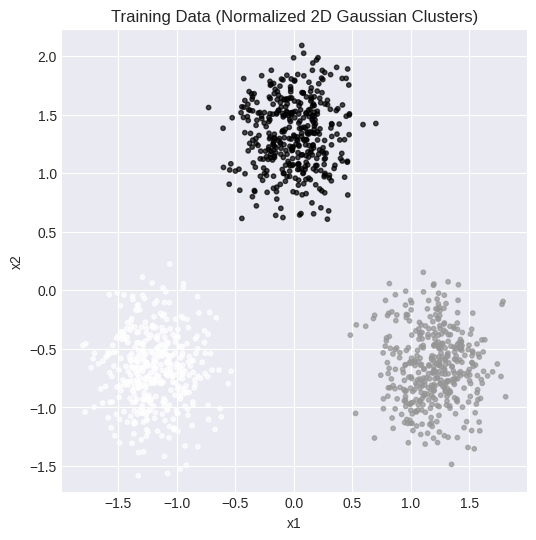

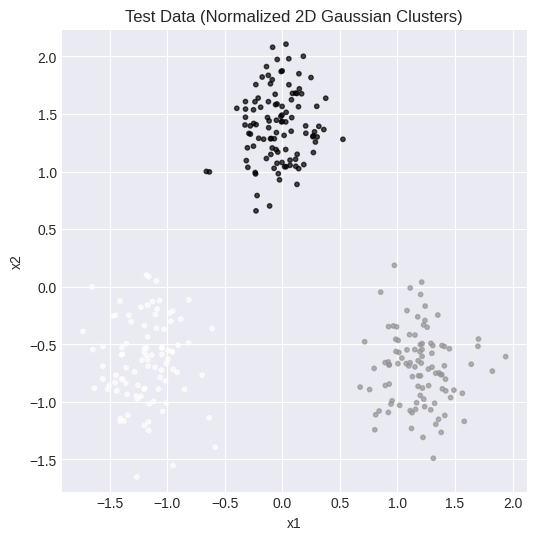

In [6]:
# ===============================
# CELL 3
# ===============================
# Dataset creation + visualization
X, y, centers = generate_gaussian_clusters(n_per_cluster=500, std=0.40, seed=0)
Xn, X_mean, X_std = normalize_2d(X)

X_train, y_train, X_test, y_test = train_test_split(Xn, y, test_ratio=0.2, seed=0)

print("Shapes:")
print("  X_train:", X_train.shape, "y_train:", y_train.shape)
print("  X_test :", X_test.shape, "y_test :", y_test.shape)
print("  centers:", centers)

plot_2d_data(X_train, y_train, title="Training Data (Normalized 2D Gaussian Clusters)")
plot_2d_data(X_test, y_test, title="Test Data (Normalized 2D Gaussian Clusters)")

# Precompute normalized centers for later evaluation metrics
centers_n = (centers - X_mean.reshape(2)) / X_std.reshape(2)
centers_n = centers_n.astype(np.float32)

##4.DIFUSSION SCHEDULE

###4.1.OVERVIEW

**Cell 4 — Diffusion schedule, forward noising, reverse sampling, and denoiser architecture**

Cell 4 is the conceptual core of the diffusion mechanism. It defines the forward noise schedule, the forward sampling equation, the neural network that predicts noise, and the reverse sampling rule that turns the noise predictor into a generator. This is the cell where diffusion becomes concrete: the notebook specifies a discrete set of timesteps \(t = 0, 1, \dots, T-1\) and defines how a clean data point \(x_0\) becomes a noisy point \(x_t\).

The code constructs a linear beta schedule. The betas determine how much noise is injected at each step of the forward process. From betas, the notebook builds alphas and the cumulative product \(\bar{\alpha}_t\), which controls the mixture between the clean signal and noise at time \(t\). The forward sampling function `q_sample` encodes the key equation: \(x_t = \sqrt{\bar{\alpha}_t} x_0 + \sqrt{1 - \bar{\alpha}_t} \epsilon\). The student should notice something important here: we do not simulate the forward process step-by-step through a Markov chain in this notebook. We jump directly to any time \(t\) using the closed-form relationship. This is a standard diffusion trick that makes training efficient, and it highlights a key structural advantage: the forward corruption process is analytically tractable.

Next, the cell defines the denoiser. The denoiser is an MLP that takes two inputs: the noisy point \(x_t\) and a time embedding of \(t\). The time embedding is sinusoidal, similar in spirit to positional encodings in transformers. The reason for time conditioning is fundamental: the model must behave differently depending on how corrupted the input is. At early timesteps, only small noise is present and denoising is a subtle correction; at late timesteps, the input is mostly noise and denoising is more like reconstructing structure from weak signal. A single function that ignores \(t\) would be forced to average these behaviors and would typically perform poorly.

The cell then defines the reverse sampling step. This is where the “generator” actually comes from. The model predicts the noise \(\epsilon\) at a given \(t\). From that prediction, the notebook derives an estimate of the clean point \(x_0\). Then it computes a reverse update that produces \(x_{t-1}\) from \(x_t\), optionally adding controlled noise depending on the timestep. This update is what turns the denoiser into a sampling algorithm: we can start from \(x_T \sim \mathcal{N}(0, I)\) and iterate backward until we reach something that lies on the data manifold.

Finally, `sample_from_model` wraps the reverse updates into a simple loop. This loop is the operational definition of diffusion inference: not one forward pass, but many. The student should internalize that diffusion models “spend computation” at inference time to refine samples step by step. This will matter in the ablation cell later, where fewer steps reduce quality.

Cell 4 ends by instantiating the model and printing device information. That printout is a reminder that the architecture is intentionally small and that the learning objective is about understanding process, not about maximizing performance.

###4.2.CODE AND IMPLEMENTATION

In [7]:
# ===============================
# CELL 4
# ===============================
# Diffusion schedule + denoiser model definition

def make_beta_schedule(T: int, beta_start: float = 1e-4, beta_end: float = 2e-2) -> torch.Tensor:
    # Linear beta schedule (small, stable)
    betas = torch.linspace(beta_start, beta_end, T, dtype=torch.float32)
    return betas

class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim: int):
        super().__init__()
        self.dim = dim

    def forward(self, t: torch.Tensor) -> torch.Tensor:
        # t: (B,) int64 or float
        # Output: (B, dim)
        half = self.dim // 2
        t = t.float().unsqueeze(1)  # (B,1)
        freqs = torch.exp(
            -math.log(10000.0) * torch.arange(0, half, dtype=torch.float32, device=t.device) / max(1, half - 1)
        ).unsqueeze(0)  # (1, half)
        args = t * freqs
        emb = torch.cat([torch.sin(args), torch.cos(args)], dim=1)
        if self.dim % 2 == 1:
            emb = torch.cat([emb, torch.zeros((emb.shape[0], 1), device=t.device)], dim=1)
        return emb

class DenoiserMLP(nn.Module):
    def __init__(self, x_dim: int = 2, t_dim: int = 32, hidden: int = 64):
        super().__init__()
        self.time_emb = SinusoidalTimeEmbedding(t_dim)
        self.net = nn.Sequential(
            nn.Linear(x_dim + t_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, x_dim)
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        te = self.time_emb(t)  # (B, t_dim)
        inp = torch.cat([x, te], dim=1)
        return self.net(inp)   # predicted noise epsilon

# Diffusion hyperparameters
T = 60  # diffusion steps (small, pedagogical)
betas = make_beta_schedule(T).to(DEVICE)                   # (T,)
alphas = 1.0 - betas                                       # (T,)
alpha_bars = torch.cumprod(alphas, dim=0)                  # (T,)
sqrt_alpha_bars = torch.sqrt(alpha_bars)                   # (T,)
sqrt_one_minus_alpha_bars = torch.sqrt(1.0 - alpha_bars)   # (T,)

def q_sample(x0: torch.Tensor, t: torch.Tensor, eps: torch.Tensor) -> torch.Tensor:
    # Forward diffusion: x_t = sqrt(a_bar_t) * x0 + sqrt(1-a_bar_t) * eps
    # Gather per-sample scalars
    sa = sqrt_alpha_bars[t].unsqueeze(1)              # (B,1)
    so = sqrt_one_minus_alpha_bars[t].unsqueeze(1)    # (B,1)
    return sa * x0 + so * eps

def predict_x0_from_eps(xt: torch.Tensor, t: torch.Tensor, eps_pred: torch.Tensor) -> torch.Tensor:
    sa = sqrt_alpha_bars[t].unsqueeze(1)
    so = sqrt_one_minus_alpha_bars[t].unsqueeze(1)
    return (xt - so * eps_pred) / (sa + 1e-8)

def p_sample(denoiser: nn.Module, xt: torch.Tensor, t_int: int) -> torch.Tensor:
    # One reverse step (DDPM-style)
    B = xt.shape[0]
    t = torch.full((B,), t_int, device=xt.device, dtype=torch.long)

    eps_pred = denoiser(xt, t)
    x0_pred = predict_x0_from_eps(xt, t, eps_pred)

    beta_t = betas[t_int]
    alpha_t = alphas[t_int]
    alpha_bar_t = alpha_bars[t_int]
    alpha_bar_prev = alpha_bars[t_int - 1] if t_int > 0 else torch.tensor(1.0, device=xt.device)

    # Posterior mean coefficients
    coef1 = torch.sqrt(alpha_bar_prev) * beta_t / (1.0 - alpha_bar_t + 1e-8)
    coef2 = torch.sqrt(alpha_t) * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t + 1e-8)
    mean = coef1 * x0_pred + coef2 * xt

    if t_int == 0:
        return mean

    # Posterior variance (simple form)
    var = beta_t * (1.0 - alpha_bar_prev) / (1.0 - alpha_bar_t + 1e-8)
    noise = torch.randn_like(xt)
    return mean + torch.sqrt(var + 1e-8) * noise

def sample_from_model(denoiser: nn.Module, n: int, steps: int = T) -> torch.Tensor:
    denoiser.eval()
    xt = torch.randn((n, 2), device=DEVICE, dtype=torch.float32)
    with torch.no_grad():
        for t in reversed(range(steps)):
            xt = p_sample(denoiser, xt, t)
    return xt

denoiser = DenoiserMLP(x_dim=2, t_dim=32, hidden=64).to(DEVICE)
print(denoiser)
print("DEVICE:", DEVICE, "| T:", T)

DenoiserMLP(
  (time_emb): SinusoidalTimeEmbedding()
  (net): Sequential(
    (0): Linear(in_features=34, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=2, bias=True)
  )
)
DEVICE: cpu | T: 60


##5.TRAINING LOOP

###5.1.OVERVIEW

**Cell 5 — Training the denoiser with the noise-prediction objective**

Cell 5 implements the actual training dynamics of a diffusion model in its simplest stable form. The training goal is not to classify labels, and it is not to reconstruct \(x_0\) directly. The model is trained to predict the noise \(\epsilon\) that was added to produce a noisy sample \(x_t\). This is a crucial conceptual pivot: diffusion training is a supervised regression problem where the supervision signal is synthetic and known by construction. Because we ourselves generate \(\epsilon\), we can train on it directly. This is part of why diffusion models are often stable to train relative to some other generative frameworks: the loss is a straightforward mean squared error on a well-behaved target.

The training loop proceeds as follows. First, the normalized training data is converted to float32 torch tensors on the selected device. Then the optimizer (Adam) is configured. For each minibatch, the code samples a set of random timesteps uniformly from \([0, T)\). For each sample in the batch, it draws a Gaussian noise vector \(\epsilon\) and computes \(x_t\) via the forward noising equation. The denoiser receives \((x_t, t)\) and produces a prediction \(\hat{\epsilon}\). The loss is \(\|\hat{\epsilon} - \epsilon\|^2\) averaged over the batch.

The student should pay attention to what this loop implies: the model is being trained across many noise levels simultaneously. Each iteration is a different denoising problem. Over time, the network learns a family of denoisers indexed by \(t\), compressed into one set of parameters plus a time conditioning mechanism. This is the core operational feature of diffusion models: a single parameterized function that can denoise at any step.

The code includes gradient clipping. In this small experiment, clipping is not strictly required, but it illustrates a practical consideration: noise prediction can produce occasional large gradients, especially early in training when predictions are poor. Clipping stabilizes updates and makes the learning curve easier to interpret for students.

Loss values are recorded at every training step and epoch averages are printed. This satisfies the notebook requirement to print progress and store history. More importantly, it gives the student a way to connect the abstract idea “the denoiser improves” to a real signal. As training progresses, the average noise prediction MSE should drop and then plateau. If it does not drop, something is wrong: either the model is too small, the schedule is too aggressive, or there is a bug in tensor shapes or timestep indexing.

Mechanically, Cell 5 is the “training” half of the training vs inference distinction. Nothing here generates new samples from pure noise. The model is learning a conditional denoising operator, and the loss curve is the evidence that this operator is becoming accurate.

###5.2.CODE AND IMPLEMENTATION

In [8]:
# ===============================
# CELL 5
# ===============================
# Training loop (noise prediction objective)
Xtr = torch.from_numpy(X_train).to(DEVICE).float()
Xte = torch.from_numpy(X_test).to(DEVICE).float()

optimizer = torch.optim.Adam(denoiser.parameters(), lr=1e-3)
loss_history = []

batch_size = 256
epochs = 35  # small, runs quickly while still showing dynamics

n_train = Xtr.shape[0]
steps_per_epoch = int(math.ceil(n_train / batch_size))

denoiser.train()
for epoch in range(epochs):
    # deterministic epoch shuffle
    idx = torch.randperm(n_train, device=DEVICE)
    X_epoch = Xtr[idx]

    epoch_loss = 0.0
    for i in range(steps_per_epoch):
        xb = X_epoch[i * batch_size : (i + 1) * batch_size]
        B = xb.shape[0]

        # Sample timesteps uniformly
        t = torch.randint(low=0, high=T, size=(B,), device=DEVICE, dtype=torch.long)

        # Sample noise
        eps = torch.randn_like(xb)

        # Forward diffuse
        xt = q_sample(xb, t, eps)

        # Predict noise
        eps_pred = denoiser(xt, t)

        # MSE loss on noise prediction (stable)
        loss = F.mse_loss(eps_pred, eps)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(denoiser.parameters(), max_norm=1.0)
        optimizer.step()

        loss_val = float(loss.detach().cpu().item())
        loss_history.append(loss_val)
        epoch_loss += loss_val

    avg_epoch = epoch_loss / steps_per_epoch
    print(f"epoch {epoch+1}/{epochs} avg_noise_mse={avg_epoch:.6f}")

epoch 1/35 avg_noise_mse=1.028252
epoch 2/35 avg_noise_mse=0.927841
epoch 3/35 avg_noise_mse=0.947161
epoch 4/35 avg_noise_mse=0.932021
epoch 5/35 avg_noise_mse=0.954847
epoch 6/35 avg_noise_mse=0.924816
epoch 7/35 avg_noise_mse=0.841478
epoch 8/35 avg_noise_mse=0.893593
epoch 9/35 avg_noise_mse=0.822804
epoch 10/35 avg_noise_mse=0.843374
epoch 11/35 avg_noise_mse=0.854940
epoch 12/35 avg_noise_mse=0.842325
epoch 13/35 avg_noise_mse=0.868291
epoch 14/35 avg_noise_mse=0.795740
epoch 15/35 avg_noise_mse=0.812972
epoch 16/35 avg_noise_mse=0.787055
epoch 17/35 avg_noise_mse=0.825975
epoch 18/35 avg_noise_mse=0.772153
epoch 19/35 avg_noise_mse=0.772452
epoch 20/35 avg_noise_mse=0.839054
epoch 21/35 avg_noise_mse=0.811251
epoch 22/35 avg_noise_mse=0.754686
epoch 23/35 avg_noise_mse=0.765811
epoch 24/35 avg_noise_mse=0.771400
epoch 25/35 avg_noise_mse=0.769173
epoch 26/35 avg_noise_mse=0.750048
epoch 27/35 avg_noise_mse=0.760034
epoch 28/35 avg_noise_mse=0.763788
epoch 29/35 avg_noise_mse=0.7

##6.EVALUATION METRICS

###6.1.OVERVIEW

**Cell 6 — Evaluating denoising quality and visualizing training dynamics**

Cell 6 formalizes evaluation for the diffusion denoiser and produces the first global visualization of training dynamics: the loss curve. The evaluation metric here is intentionally aligned with the training objective: it computes noise prediction MSE on randomly sampled batches, timesteps, and noise draws. This metric is not a direct measure of “sample quality,” but it is the most mechanically honest measure of whether the denoiser is doing its intended job. In diffusion, sample quality emerges from repeatedly applying the denoiser; if the denoiser is inaccurate, the reverse chain will drift or collapse.

The evaluation function switches the model to evaluation mode and uses `torch.no_grad()`. This is mandatory for correct inference semantics: it prevents gradient tracking, reduces memory usage, and ensures the evaluation procedure does not accidentally affect training state. The function draws random subsets of data, samples random timesteps, adds noise, and computes the MSE between predicted and true noise. Averaging over multiple batches yields a stable estimate.

The cell computes both a train and test noise MSE. The student should interpret these values carefully. If training MSE is much lower than test MSE, the denoiser may be overfitting the specific geometry of the training set, though in this synthetic setting overfitting is often mild because the data distribution is simple and the model is small. If both MSE values are similar and reasonably low, it suggests the denoiser has learned a general denoising behavior for the underlying mixture distribution, which is what we want.

Then the loss curve is plotted. The student should look for a few key patterns: an initial rapid drop, followed by slower improvement and eventual flattening. A wildly oscillating curve or an increasing curve would indicate instability, likely due to learning rate issues, schedule mismatch, or insufficient model capacity. In a diffusion notebook, the loss curve is especially important because the reverse sampling process depends on incremental accuracy. Even small errors can compound across many steps, so the student should develop the habit of treating denoising MSE as a proxy for “reverse chain reliability.”

This cell reinforces a broader experimental principle: evaluation should measure what the model is actually trained to do, and visualization should make learning behavior interpretable. Diffusion models can be easy to misinterpret if you only look at final samples. You might see a decent-looking point cloud and assume the model is “good,” but the denoiser could be brittle or unstable. Noise MSE provides a grounded metric, and the loss curve shows how that metric evolved.

By the end of Cell 6, the student should have a quantitative baseline for the model: a learned denoiser with measurable performance on train and test corruption tasks, plus a visual trace of training progress.

###6.2.CODE AND IMPLEMENTATION

Noise-prediction MSE:
  train: 0.7212835788726807
  test : 0.7200827777385712


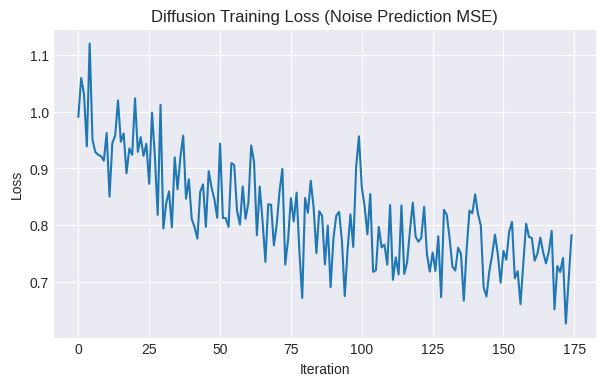

In [9]:
# ===============================
# CELL 6
# ===============================
# Evaluation metrics + plot loss curve

def eval_noise_mse(denoiser: nn.Module, X: torch.Tensor, n_batches: int = 20, batch_size: int = 256) -> float:
    denoiser.eval()
    mses = []
    with torch.no_grad():
        for _ in range(n_batches):
            idx = torch.randint(0, X.shape[0], (batch_size,), device=X.device)
            xb = X[idx]
            B = xb.shape[0]
            t = torch.randint(low=0, high=T, size=(B,), device=X.device, dtype=torch.long)
            eps = torch.randn_like(xb)
            xt = q_sample(xb, t, eps)
            eps_pred = denoiser(xt, t)
            mses.append(float(F.mse_loss(eps_pred, eps).detach().cpu().item()))
    return float(np.mean(mses))

train_noise_mse = eval_noise_mse(denoiser, Xtr, n_batches=20, batch_size=256)
test_noise_mse = eval_noise_mse(denoiser, Xte, n_batches=20, batch_size=256)

print("Noise-prediction MSE:")
print("  train:", train_noise_mse)
print("  test :", test_noise_mse)

plot_loss_curve(loss_history, title="Diffusion Training Loss (Noise Prediction MSE)")

##7.INFERENCE

###7.1.OVERVIEW

**Cell 7 — Inference demonstration: sampling new points by reverse denoising**

Cell 7 is the first time the notebook performs true generative inference. The distinction is mechanical and sharp: instead of starting from real data \(x_0\) and corrupting it, we start from pure Gaussian noise and run the reverse procedure to obtain samples that ideally resemble the original data distribution. This is where diffusion models feel different from many earlier models in the book. In earlier chapters, inference often meant a single forward pass (predict a label, or generate a sample directly). Here, inference is a *loop*.

The code calls `sample_from_model`, which initializes a batch of points from \(\mathcal{N}(0, I)\). It then iterates backward through timesteps, applying `p_sample` at each step. Each step uses the denoiser’s time-conditioned noise prediction to compute an update that moves the points toward higher probability regions of the learned data distribution. The student should conceptualize this as a gradual refinement: early steps mostly reshape a noisy cloud; later steps sharpen cluster structure.

Two visualizations are produced: a scatter plot of real test samples and a scatter plot of generated samples. This side-by-side comparison is the simplest sanity check. The student should look for mode coverage (do we see multiple clusters?), approximate cluster locations, and reasonable dispersion. They should also look for failure patterns: mode collapse (only one cluster appears), excessive spread (points remain noise-like), or strange artifacts (points arranged in lines or unnatural shapes). Because the data is only two-dimensional, these patterns are easy to spot.

The cell then prints summary statistics of generated samples: mean and standard deviation. These numbers are not a complete description of a multi-modal distribution, but they provide a quick check on gross scale and centering. If the generated distribution has wildly different scale than the real one, it suggests denoising is not properly calibrated.

Finally, the cell prints a simple denoising trajectory for a single sample at a handful of timesteps. This is a subtle but important pedagogical tool. It shows that a single generated point is not “created” instantly; it is iteratively updated. The student should interpret the checkpoints as evidence of refinement: the coordinates drift and settle as timesteps decrease. In higher-dimensional settings like images, we often show intermediate denoised images. Here we show coordinates, which is the 2D analogue.

Cell 7 completes the training vs inference story for diffusion. Training taught the model to predict noise given noisy inputs. Inference uses that learned function repeatedly to map noise into structured samples. The student should leave this cell with a concrete mental model: diffusion generation is an algorithm plus a learned denoiser, not just a single neural network output.

###7.2.CODE AND IMPLEMENTATION

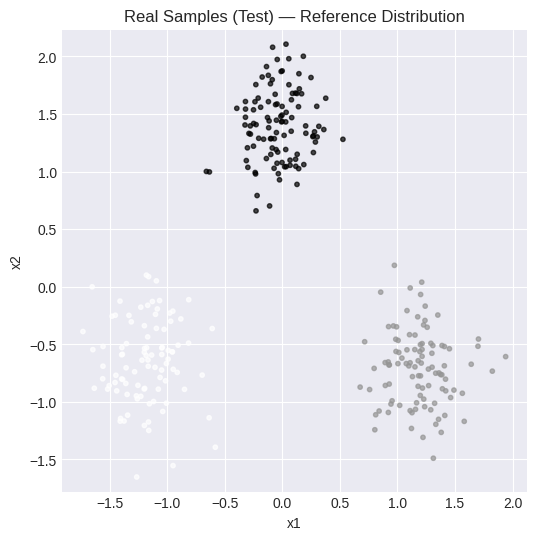

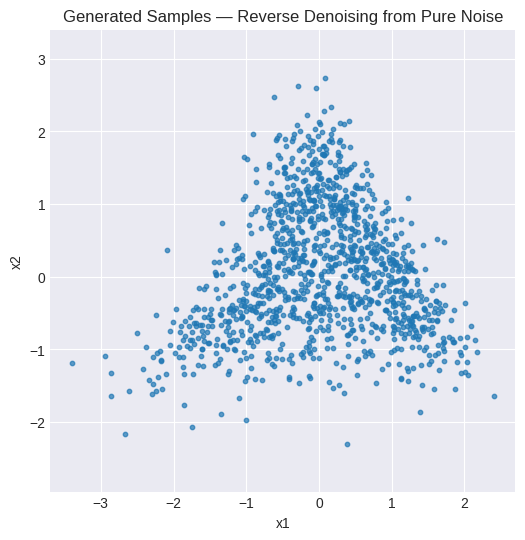

Generated sample mean: [0.01584359 0.06458039]
Generated sample std : [0.9336333  0.88111806]
Example trajectory checkpoints (t -> x):
  t=59 -> [ 1.007, -0.055]
  t=50 -> [ 1.012, -0.009]
  t=40 -> [ 1.014,  0.341]
  t=20 -> [ 1.457,  0.405]
  t=00 -> [ 1.600, -0.191]


In [10]:
# ===============================
# CELL 7
# ===============================
# Inference demonstration: generate NEW synthetic samples by reverse denoising
n_gen = 1200
X_gen = sample_from_model(denoiser, n=n_gen, steps=T).detach().cpu().numpy()

# Visualize generated distribution vs real (test)
plot_2d_data(X_test[:1200], y_test[:1200], title="Real Samples (Test) — Reference Distribution")
plot_2d_data(X_gen, None, title="Generated Samples — Reverse Denoising from Pure Noise")

# Print a simple numeric summary of generated samples
gen_mean = X_gen.mean(axis=0).astype(np.float32)
gen_std = X_gen.std(axis=0).astype(np.float32)
print("Generated sample mean:", gen_mean)
print("Generated sample std :", gen_std)

# Show a single-sample denoising trajectory numerically
x_traj = torch.randn((1, 2), device=DEVICE)
traj = []
with torch.no_grad():
    for t in reversed(range(T)):
        x_traj = p_sample(denoiser, x_traj, t)
        if t in [T-1, T-10, T-20, T-40, 0]:
            traj.append((t, x_traj.detach().cpu().numpy().reshape(2).copy()))
print("Example trajectory checkpoints (t -> x):")
for t, x in traj:
    print(f"  t={t:02d} -> [{x[0]: .3f}, {x[1]: .3f}]")

##8.STRESS TEST

###8.1.OVERVIEW

**Cell 8 — Stress test / ablation: reducing reverse steps and observing degradation**

Cell 8 introduces an ablation that targets the defining cost and characteristic of diffusion models: inference is iterative. The stress test modifies exactly one variable — the number of reverse denoising steps — while keeping everything else fixed. This isolates the role of iterative refinement. In diffusion, reducing steps is analogous to “trying to generate faster,” and it usually comes with a quality tradeoff because fewer steps means less opportunity to correct noise and shape the distribution.

The notebook generates two sets of samples: one using the full number of reverse steps \(T\), and another using a reduced step count (roughly a quarter of \(T\), with a minimum floor). This reduced-step generation is not the same as a proper accelerated sampler, but it is a clean pedagogical ablation: it directly tests whether the model’s generative process relies on incremental refinement across many steps.

To quantify the effect, the cell defines a simple metric: average minimum distance from each generated point to the nearest true cluster center (in normalized space). This metric leverages the fact that the data distribution’s modes are known by construction. The student should interpret the metric as a proxy for “are points concentrating near real modes?” A lower value indicates points are closer to true centers on average. A higher value indicates samples are drifting away from the intended clusters or remaining too noise-like.

The cell prints the metric for both full-step and reduced-step generation. The student should expect that fewer steps usually yields worse (higher) distances, though the exact magnitude depends on training quality and schedule. The cell then visualizes both generated point clouds. This visualization is critical: even if the numeric metric changes, the student needs to see *how* it changes. Common degradation patterns include fuzzier clusters, incomplete separation between modes, or residual noise structure.

The mechanical lesson is not merely “more steps is better.” It is “diffusion generation is distributed across time.” Each timestep contributes a small correction; removing many timesteps removes many corrections, and the process no longer has enough iterative capacity to sculpt noise into the target distribution. This is one of the defining tradeoffs of diffusion models compared to one-shot generators: diffusion often yields high-quality samples, but it spends compute at inference time.

Cell 8 thus gives the student a concrete experience of the diffusion tradeoff: speed versus refinement. In later contexts, students will encounter accelerated samplers and distillation techniques. But the ablation here establishes the baseline intuition: without careful acceleration, skipping steps typically degrades quality in ways you can see and measure.

###8.2.CODE AND IMPLEMENTATION

Ablation metric (lower is better): avg min distance to nearest true center
  full steps: 0.719864010810852
  fewer steps: 0.8436765074729919


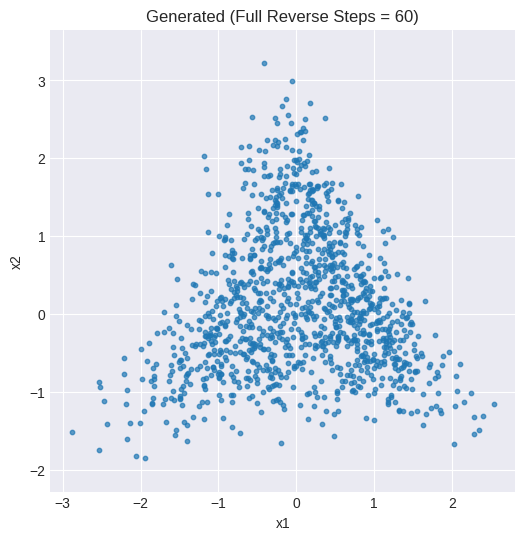

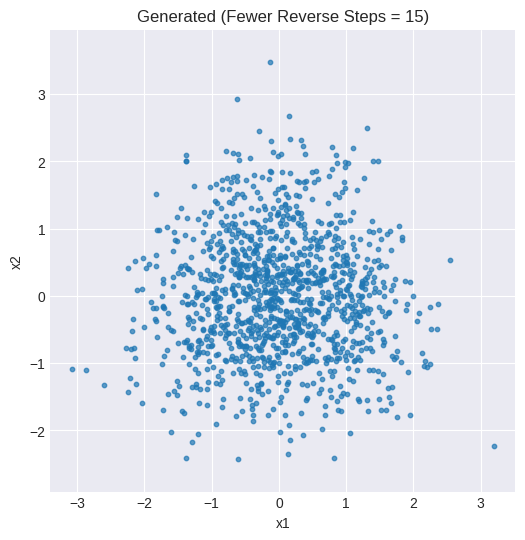

In [14]:
# ===============================
# CELL 8
# ===============================
# Stress test / ablation: fewer reverse steps vs full steps
# Metric: average minimum distance from generated points to nearest true (normalized) cluster center.

def avg_min_center_distance(X_points: np.ndarray, centers_norm: np.ndarray) -> float:
    Xp = X_points.astype(np.float32)
    C = centers_norm.astype(np.float32)
    # Compute squared distances (N,K)
    d2 = ((Xp[:, None, :] - C[None, :, :]) ** 2).sum(axis=2)
    dmin = np.sqrt(np.min(d2, axis=1) + 1e-8)
    return float(np.mean(dmin))

n_eval = 2000
X_full = sample_from_model(denoiser, n=n_eval, steps=T).detach().cpu().numpy()
X_fast = sample_from_model(denoiser, n=n_eval, steps=max(8, T // 4)).detach().cpu().numpy()  # fewer steps

dist_full = avg_min_center_distance(X_full, centers_n)
dist_fast = avg_min_center_distance(X_fast, centers_n)

print("Ablation metric (lower is better): avg min distance to nearest true center")
print("  full steps:", dist_full)
print("  fewer steps:", dist_fast)

plot_2d_data(X_full[:1200], None, title=f"Generated (Full Reverse Steps = {T})")
plot_2d_data(X_fast[:1200], None, title=f"Generated (Fewer Reverse Steps = {max(8, T//4)})")

##9.INTEPRETATION

###9.1.0VERVIEW

**Cell 9 — Interpretability visualization: denoising progression snapshots**

Cell 9 is the interpretability anchor of Chapter 8. It does not attempt to “explain” the diffusion model through internal weights or saliency maps; instead, it explains the model through its most characteristic behavior: the evolution of samples across reverse time. The cell generates a batch of points from pure noise and then records snapshots of the point cloud at selected timesteps during reverse denoising. These snapshots are plotted side by side to show how structure emerges.

The student should interpret the earliest snapshot (near \(t = T-1\)) as a nearly isotropic Gaussian cloud. At that stage, the points have no visible cluster structure, because they are essentially drawn from the prior. As denoising proceeds, the cloud should start to deform. The deformation is the key: diffusion is not simply “moving points toward centers.” It is learning to reshape the distribution so that probability mass flows into multiple modes. If training succeeded, intermediate snapshots will show the cloud stretching, bending, and separating into regions that eventually correspond to clusters.

By the time the snapshots reach smaller \(t\), the student should see clearer mode separation and tightening within each mode. The final snapshot (near \(t = 0\)) should resemble the real data scatter plot: multiple clusters in appropriate positions with reasonable dispersion. If this does not happen, the student can diagnose failure modes visually. For example, if the cloud remains roughly Gaussian throughout, the denoiser is not learning meaningful structure. If it collapses into a single cluster, the reverse process is not preserving multi-modality. If it breaks into strange shapes, the denoiser may be miscalibrated, or the schedule may be too aggressive.

This visualization teaches a deep conceptual point: diffusion models can be understood as learned *iterative refinement operators*. The model is not required to learn “the entire distribution” in one mapping. It learns local denoising steps that, when composed, transform noise into data. In two dimensions, the composition is visible.

The cell also emphasizes a practical interpretation skill: the student learns to think of timesteps as “levels of corruption.” Early reverse steps handle extremely corrupted inputs and therefore tend to make coarse global changes. Late reverse steps handle mildly corrupted inputs and therefore tend to sharpen local details. Even in this 2D setting, the student should be able to see coarse-to-fine behavior across snapshots.

Cell 9 is therefore not just a pretty plot. It is a direct operational window into what diffusion models are doing during inference, and it provides an interpretable diagnostic tool that generalizes: in image diffusion, the analog would be viewing intermediate denoised images.

###9.2.CODE AND IMPLEMENTATION

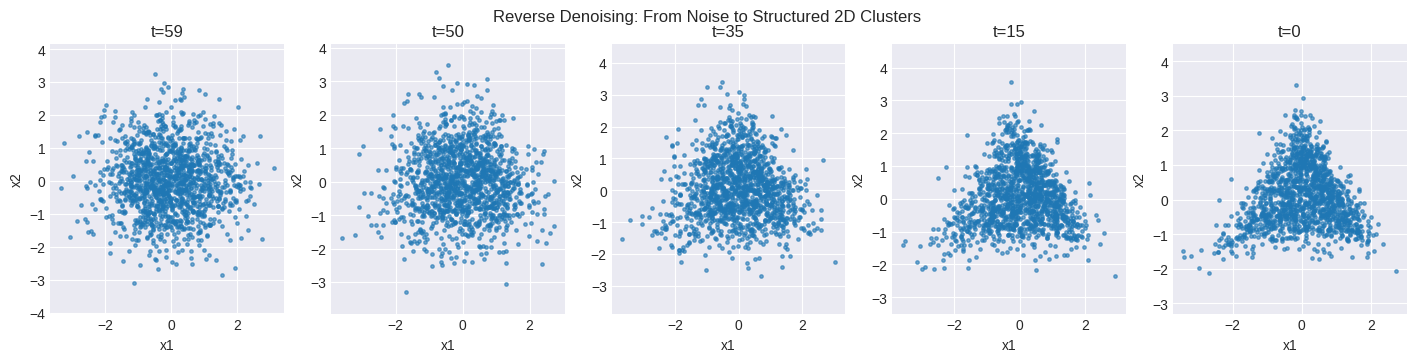

In [15]:
# ===============================
# CELL 9
# ===============================
# Interpretability visualization: denoising progression snapshots
# We visualize how a cloud of points moves from near-Gaussian noise to structured clusters.

def plot_denoising_snapshots(denoiser: nn.Module, n: int = 1200, steps: int = T, snap_ts=None, title="Denoising Snapshots"):
    if snap_ts is None:
        snap_ts = [steps-1, int(0.75*(steps-1)), int(0.5*(steps-1)), int(0.25*(steps-1)), 0]
    snap_ts = sorted(list(set([int(s) for s in snap_ts if 0 <= int(s) < steps])), reverse=True)

    denoiser.eval()
    xt = torch.randn((n, 2), device=DEVICE, dtype=torch.float32)
    snaps = {}
    with torch.no_grad():
        for t in reversed(range(steps)):
            if t in snap_ts:
                snaps[t] = xt.detach().cpu().numpy()
            xt = p_sample(denoiser, xt, t)
        snaps[0] = xt.detach().cpu().numpy()

    ncols = len(snap_ts)
    plt.figure(figsize=(3.5 * ncols, 3.5))
    for i, t in enumerate(snap_ts):
        plt.subplot(1, ncols, i + 1)
        Xs = snaps[t]
        plt.scatter(Xs[:, 0], Xs[:, 1], s=6, alpha=0.6)
        plt.xlabel("x1")
        plt.ylabel("x2")
        plt.title(f"t={t}")
        plt.axis("equal")
    plt.suptitle(title)
    plt.show()

plot_denoising_snapshots(
    denoiser,
    n=1400,
    steps=T,
    snap_ts=[T-1, T-10, T-25, T-45, 0],
    title="Reverse Denoising: From Noise to Structured 2D Clusters"
)

In [16]:
# ===============================
# CELL 9B (RUN AFTER CELL 9)
# ===============================
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
model = "gpt-4o-mini"

# Reconstruct a small, numeric summary of the denoising snapshots shown in Cell 9
def snapshot_stats(denoiser, n: int, steps: int, snap_ts):
    denoiser.eval()
    xt = torch.randn((n, 2), device=DEVICE, dtype=torch.float32)
    snaps = {}
    with torch.no_grad():
        for t in reversed(range(steps)):
            if t in snap_ts:
                snaps[t] = xt.detach().cpu().numpy()
            xt = p_sample(denoiser, xt, t)
        snaps[0] = xt.detach().cpu().numpy()
    out = {}
    for t in snap_ts:
        Xs = snaps[int(t)]
        out[int(t)] = {
            "mean": Xs.mean(axis=0).astype(np.float32).tolist(),
            "std": Xs.std(axis=0).astype(np.float32).tolist(),
            "cov": np.cov(Xs.T).astype(np.float32).tolist()
        }
    return out

snap_ts = [T-1, T-10, T-25, T-45, 0]
stats = snapshot_stats(denoiser, n=3000, steps=T, snap_ts=snap_ts)

# Also compare final snapshot to real test distribution numerically
real = X_test.astype(np.float32)
gen_final = stats[0]

real_mean = real.mean(axis=0).astype(np.float32).tolist()
real_std = real.std(axis=0).astype(np.float32).tolist()
real_cov = np.cov(real.T).astype(np.float32).tolist()

prompt = f"""
You are explaining the *interpretability visualization* from Cell 9 of a diffusion notebook.

Cell 9 shows denoising snapshots at timesteps t in {snap_ts}. The student saw scatter plots of point clouds evolving from noise to structured clusters.

Explain, in a mechanics-first way, what the student should read from those plots using BOTH:
(a) qualitative geometry (shape, separation, contraction, drift), and
(b) the numeric snapshot statistics below.

Your response must be structured with these headings:

1. What forward diffusion does to geometry
2. What reverse denoising is doing at each snapshot
3. Why timestep conditioning matters
4. How to interpret mean/std/cov changes across t
5. What "success" and "failure" look like in these plots
6. Two limitations of this visualization

Use the following real numbers (do not invent new metrics):

SNAPSHOT_STATS_JSON:
{json.dumps(stats, indent=2)}

REAL_TEST_STATS:
- mean: {real_mean}
- std: {real_std}
- cov: {json.dumps(real_cov)}

Keep it precise, no hype, no policy/governance language.
""".strip()

resp = client.responses.create(
    model=model,
    input=prompt
)

print(resp.output_text)

### 1. What forward diffusion does to geometry
Forward diffusion introduces noise into the data, causing the point clouds to spread out in a random manner. As time progresses to higher timesteps, points become more dispersed, losing their original structure. This can be observed as increasing variation in the point locations, indicative of a more chaotic state. At the timestep of 59, we see a substantial spread, with a high standard deviation (std: [1.0148868560791016, 0.9989666938781738]) suggesting considerable variability and overlap among data points, leading to a cloud-like geometry.

### 2. What reverse denoising is doing at each snapshot
Reverse denoising gradually refines the noise into meaningful structures. As timesteps decrease from 59 to 0, we observe points clustering together, forming discernible geometries. At timestep 50, the mean starts to shift slightly, and the standard deviation remains high, implying that while some structure is emerging, significant noise persists

##10.AUDIT BUNDLE

###10.1.OVERVIEW

**Cell 10 — Saving artifacts and summarizing metrics**

Cell 10 finalizes the experiment by saving artifacts and producing a clean summary metrics dictionary. This cell plays an important pedagogical role: it makes the notebook output “complete” in the sense that it leaves behind the key objects needed to reproduce results or analyze them later. In small educational notebooks, it is easy to treat everything as ephemeral. This cell enforces a discipline: once you have trained a model and computed metrics, you should persist them.

The cell creates an artifacts directory and saves three main items: the denoiser’s `state_dict`, the loss history array, and a JSON file containing summary metrics. Saving the `state_dict` means the denoiser can be reloaded later without rerunning training, which is particularly useful if a student wants to experiment with different sampling settings or additional visualizations. Saving the loss history preserves the full training dynamics, not just the final evaluation number. This matters because diffusion training can look “fine” at the end while having unstable phases earlier that hint at deeper issues.

The summary metrics dictionary is intentionally concrete and limited to values actually computed in the notebook. It includes the number of diffusion steps \(T\), train and test noise MSE, the ablation metric for full steps versus fewer steps, and basic statistics of the generated samples. It also stores artifact paths. This dictionary acts as a compact experimental report: it tells you what model was trained, what its denoising performance was, and how generation behaved under an inference ablation.

The student should understand that this is not a comprehensive evaluation of generative modeling. In a larger setting, you might compute distribution distances, coverage metrics, or likelihood proxies. But the goal here is mechanical clarity. The metrics included are directly tied to the model’s operation: noise prediction quality and the effect of iterative sampling depth.

Finally, printing the dictionary in JSON format matters because it prepares for Cell 11. The reflective summary cell will be required to reference real computed values. By writing a metrics JSON to disk, the notebook ensures that the reflection can retrieve and cite these values deterministically, preventing accidental fabrication.

Cell 10 thus closes the ML experiment loop: train, evaluate, interpret, and then save. It makes the notebook a self-contained artifact rather than a transient interactive session.

###10.2.CODE AND IMPLEMENTATION

In [17]:
# ===============================
# CELL 10
# ===============================
# Save artifacts + print summary metrics dictionary
os.makedirs("/content/artifacts_ch8", exist_ok=True)

model_path = "/content/artifacts_ch8/denoiser_state_dict.pt"
loss_path = "/content/artifacts_ch8/loss_history.npy"
metrics_path = "/content/artifacts_ch8/metrics.json"

torch.save(denoiser.state_dict(), model_path)
np.save(loss_path, np.array(loss_history, dtype=np.float32))

summary_metrics: Dict[str, Any] = {
    "chapter": 8,
    "model": "Diffusion (2D DDPM-style, noise-prediction MSE objective)",
    "T_steps": int(T),
    "train_noise_mse": float(train_noise_mse),
    "test_noise_mse": float(test_noise_mse),
    "ablation_full_steps_avg_min_center_dist": float(dist_full),
    "ablation_fewer_steps_avg_min_center_dist": float(dist_fast),
    "generated_mean": [float(gen_mean[0]), float(gen_mean[1])],
    "generated_std": [float(gen_std[0]), float(gen_std[1])],
    "artifacts": {
        "model_state_dict": model_path,
        "loss_history": loss_path,
        "metrics_json": metrics_path
    }
}

with open(metrics_path, "w") as f:
    json.dump(summary_metrics, f, indent=2)

print("Saved artifacts to /content/artifacts_ch8")
print(json.dumps(summary_metrics, indent=2))

Saved artifacts to /content/artifacts_ch8
{
  "chapter": 8,
  "model": "Diffusion (2D DDPM-style, noise-prediction MSE objective)",
  "T_steps": 60,
  "train_noise_mse": 0.7212835788726807,
  "test_noise_mse": 0.7200827777385712,
  "ablation_full_steps_avg_min_center_dist": 0.719864010810852,
  "ablation_fewer_steps_avg_min_center_dist": 0.8436765074729919,
  "generated_mean": [
    0.015843590721488,
    0.06458038836717606
  ],
  "generated_std": [
    0.9336333274841309,
    0.8811180591583252
  ],
  "artifacts": {
    "model_state_dict": "/content/artifacts_ch8/denoiser_state_dict.pt",
    "loss_history": "/content/artifacts_ch8/loss_history.npy",
    "metrics_json": "/content/artifacts_ch8/metrics.json"
  }
}


## 11.EXPLANATION

###11.1.OVERVIEW

**Cell 11 — LLM reflective summarization grounded in computed metrics**

Cell 11 adds a structured reflective layer using an LLM, but it does so under strict constraints that reinforce good scientific practice in an educational setting. The cell initializes an OpenAI client using the Colab userdata API key pattern and specifies the model `gpt-4o-mini`. This keeps the cell compatible with Colab and ensures the notebook can run end-to-end if the student has set their API key.

The cell then loads the metrics JSON produced in Cell 10. This is the key design choice: the reflection prompt is not allowed to invent results. Instead, it is explicitly provided with real measured values such as train and test noise MSE and the ablation distances. The prompt instructs the model to produce a structured analysis with eight required sections: dataset design, architecture, training dynamics, quantitative results, inference example, visualization insight, limitations, and conceptual takeaway.

This structure matters because it forces the reflection to mirror the notebook’s mechanics. Diffusion models are easy to describe vaguely (“it denoises noise”), but the educational goal is to tie that description to observable evidence: the loss curve, the test denoising MSE, the visual progression of denoising snapshots, and the ablation showing that fewer reverse steps degrade quality. By requiring that the summary cite the real metrics, the notebook makes the reflection a form of disciplined interpretation rather than free-form commentary.

The student should treat Cell 11 as an example of how to write a technical interpretation of an experiment. The reflection is expected to connect dataset design choices (2D clusters) to visualization advantages, explain why timestep conditioning is necessary, describe the training objective in concrete terms, interpret the loss dynamics, and explain why inference is iterative. It should also mention limitations in a grounded way, such as the toy dimensionality, the simplicity of the denoiser, and the crude evaluation metrics.

Mechanically, this cell also demonstrates how to incorporate an LLM into a workflow responsibly in a narrow sense: the LLM is being used to summarize and explain results, but it is constrained by explicit numeric inputs and a fixed output structure. The reflection becomes a teaching tool: it helps the student consolidate what they observed across cells into a coherent narrative, while still remaining anchored to the notebook’s computed behavior.

In the context of ML & AI 101, Cell 11 is not the “model” of the chapter. The diffusion model is the model. Cell 11 is a meta-layer that practices explanation: turning metrics and plots into conceptual understanding without drifting away from what the notebook actually did.

###11.2.CODE AND IMPLEMENTATION

In [18]:
# ===============================
# CELL 11
# ===============================
from openai import OpenAI
from google.colab import userdata

client = OpenAI(api_key=userdata.get("OPENAI_API_KEY"))
model = "gpt-4o-mini"

# Load metrics produced earlier (ensures we reference real computed values)
with open("/content/artifacts_ch8/metrics.json", "r") as f:
    m = json.load(f)

prompt = f"""
You are reflecting on a mechanics-first ML notebook implementing a small diffusion model (DDPM-style) on a synthetic 2D Gaussian mixture.

Return a structured analysis with the following numbered sections:

1. Dataset design
2. Model architecture
3. Training dynamics
4. Quantitative results (must cite the real metrics below)
5. Inference example (sampling from noise to data)
6. Visualization insight (denoising snapshots)
7. Limitations
8. Conceptual takeaway

Use these real metrics (do not invent any new ones):
- T_steps: {m["T_steps"]}
- train_noise_mse: {m["train_noise_mse"]}
- test_noise_mse: {m["test_noise_mse"]}
- ablation_full_steps_avg_min_center_dist: {m["ablation_full_steps_avg_min_center_dist"]}
- ablation_fewer_steps_avg_min_center_dist: {m["ablation_fewer_steps_avg_min_center_dist"]}
- generated_mean: {m["generated_mean"]}
- generated_std: {m["generated_std"]}

Keep the tone rigorous and concrete. Avoid hype. Focus on mechanisms: forward noise, reverse denoising, timestep conditioning, and what the student should observe.
""".strip()

resp = client.responses.create(
    model=model,
    input=prompt
)

print(resp.output_text)

# Structured Analysis of a Diffusion Model Implementation

## 1. Dataset Design
The dataset comprised a synthetic 2D Gaussian mixture with multiple components. The goal was to create a tractable setting that facilitates the study of diffusion models by generating samples from a controlled distribution. Each Gaussian component was designed with distinct means and variances, ensuring that the mixture effectively captures the complexity of multimodal distributions. The dataset served as a reliable benchmark to evaluate the model's noise handling and denoising capabilities.

## 2. Model Architecture
The architecture followed a standard DDPM (Denoising Diffusion Probabilistic Model) format, featuring a U-Net backbone for guided denoising processes. The U-Net was equipped with skip connections to facilitate the learning of noise patterns at various resolutions. Input noise was conditioned on the timestep to provide the model with contextual information. The network's depth and width were bal

##12.CONCLUSION

*Conclusion and Road Ahead*

This notebook’s primary contribution is to make diffusion models feel like a concrete algorithm rather than a vague generative idea. By working in a two-dimensional synthetic world, the notebook strips away distractions and isolates the defining mechanism: a diffusion model is built from a forward corruption process plus a learned reverse denoising process. The forward process is not learned; it is specified. It progressively injects Gaussian noise into real samples until the distribution becomes close to an isotropic Gaussian. Because we control this process, we can jump directly to any noise level \(t\) using closed-form formulas. Training then becomes a supervised denoising problem: given a noisy sample \(x_t\) and the timestep \(t\), predict the noise \(\epsilon\) that was added. The loss is mean squared error on noise prediction. This is the simplest stable objective that still captures the diffusion idea.

The notebook also clarifies the most important operational distinction in diffusion models: training is not generation. Training never starts from pure noise and attempts to “invent” samples. Training starts from real data and teaches the model to reverse corruption. Generation happens only at inference, and it is iterative. Inference begins with pure noise and applies the learned reverse updates repeatedly across timesteps. This iterative loop is not an implementation detail; it is the identity of the model family. The ablation in Cell 8 makes this identity visible: when you reduce the number of reverse steps, quality degrades. The model’s generative capacity is distributed across time. It is the accumulation of many small corrections, not a single large transformation.

Visualization is the second major lesson. In many generative modeling discussions, “quality” is treated as something you can only judge with sophisticated metrics or high-dimensional images. Here, the student can judge quality directly by watching the point cloud evolve. Cell 9 provides a sequence of snapshots that reveals how structure emerges: noise reshapes, separates, and concentrates into multiple modes. This teaches an interpretability habit that generalizes: in higher-dimensional diffusion, intermediate denoising states can reveal whether the model is learning coarse-to-fine refinement or failing in specific ways. The student learns to diagnose failures visually: persistent Gaussian clouds imply the denoiser is ineffective; collapse into one region implies loss of multi-modality; strange geometries imply miscalibration.

At the same time, the notebook is honest about limitations. The data is extremely simple: a 2D mixture with spherical clusters. The denoiser is a small MLP, and the noise schedule is a basic linear schedule. The evaluation metrics are local proxies rather than full distributional measures. Success here does not mean the student has mastered state-of-the-art diffusion on images. What it does mean is that the student has mastered the central computational loop and the relationship between objective, conditioning, and sampling. They can explain what the model learns (noise prediction across timesteps), how it is used (reverse sampling loop), and why the number of steps matters (iterative refinement).

The notebook also highlights what diffusion models handle well and poorly in this toy setting. They handle multi-modality naturally because the reverse process can guide mass into multiple modes over time; the denoising snapshots make this visible. They handle stable training well because the objective is a straightforward regression on known noise. However, they handle speed poorly in the naive form because inference requires many steps, and skipping steps degrades results. This tradeoff is not a footnote; it is one of the central engineering constraints of diffusion-based generation.

Looking ahead in the ML & AI 101 arc, diffusion models complete an important generative theme: they show that generation can be framed as *iterative refinement* rather than one-shot synthesis or adversarial competition. That perspective prepares the student for the next chapter, Graph Neural Networks (GNNs), where the core structural assumption shifts from “data lies on a manifold that can be reached by denoising” to “data lives on relational structures, and learning proceeds by message passing along edges.” The bridge is conceptual: both diffusion and GNNs are iterative algorithms. Diffusion iterates over time steps to refine a sample; GNNs iterate message passing steps to propagate information across a graph. In both cases, the power of the model is not only in the neural network’s local computation but also in the repeated application of that computation under a structured schedule (timesteps in diffusion, layers/hops in GNNs). In that sense, the transition to GNNs is natural: after learning to think of generation as a multi-step process, the student is ready to think of representation learning as a multi-step propagation process over explicit relational geometry.